# Empirical Covariance of Periodogram Ordinates — Independence Check

## 목적

Whittle / Debiased-Whittle likelihood는 서로 다른 주파수 $\omega_j \neq \omega_k$에서  
**periodogram ordinates $I_j$, $I_k$가 (점근적으로) 독립**이라고 가정한다.

실제 GEMS TCO 데이터(7월 2024)에서 이 가정이 얼마나 유효한지 확인한다.

$$\text{Cov}_{\text{emp}}(I_j, I_k) = \frac{1}{D}\sum_{d=1}^D (I_d(\omega_j) - \hat{f}_j)(I_d(\omega_k) - \hat{f}_k)$$

**Wick 기준선**: Hann taper만으로 생기는 coupling (stationary Gaussian field 가정)  
$$\text{Cov}_{\text{theo}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{H^2}[j-k]|^2 + |F_{H^2}[j+k]|^2}{(MN)^2}$$

**핵심 질문**: $\text{Cov}_{\text{emp}} \gg \text{Cov}_{\text{theo}}$이면 taper 이상의 coupling 존재  
→ 독립성 가정 위반, 어느 주파수 대역에서 가장 심한가?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# GEMS grid dimensions (July 2024, lat[-3,2], lon[121,131])
M, N   = 114, 159       # lat × lon
DLAT   = 0.044          # degrees/cell (lat)
DLON   = 0.063          # degrees/cell (lon)

# 2D Hann taper — unnormalized.
# Effective taper: g^(q)_s = h_s · 1[s ∈ O^(q)]  (mask baked in)
# H_q = Σ_s (g^(q)_s)²  adapts to actual observed cells
# J^(q)(ω_k) = FFT(g^(q) ⊙ X^(q))[k] / (2π√H_q)  → E[I^(q)(ω)] ≈ f(ω)/(2π)²
h = np.outer(np.hanning(M), np.hanning(N))

print(f"Grid: {M}×{N}  |  unnormalized Hann, h_center = {h[M//2, N//2]:.4f}")

Grid: 114×159  |  unnormalized Hann, h_center = 0.9998


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency selection: 3 bands × 3 frequencies = 9 total
#
# Grid: M=114 lat, N=159 lon  |  0.044°/cell lat,  0.063°/cell lon
# Spatial scale at index j:  λ_lat = M/j1 * DLAT,  λ_lon = N/j2 * DLON
#
# Band   j1 range   λ_lat           Physical meaning
# Low    1–3        1.7°–5.0°       domain-scale O3 gradient
# Mid    8–20       0.25°–0.62°     mesoscale variability
# High   30–55      0.09°–0.17°     small-scale / near Nyquist
# ─────────────────────────────────────────────────────────────────────────────

FREQ_BANDS = {
    # "Low" replaced with "Near": adjacent lon-freq pairs (sep=(0,1))
    # Gaussian baseline predicts corr~0.45 for Near pairs → non-trivial comparison
    # Original Low band (1,1),(2,3),(3,5) had sep in BOTH dims → baseline trivially 0
    "Near": [(5,8),  (5,9),   (5,10)],
    "Mid":  [(8,13), (12,19), (18,28)],
    "High": [(35,55),(44,68), (54,77)],
}

FREQ_ALL    = []
BAND_LABELS = []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)
K = len(FREQ_ALL)

print(f"{'#':>3}  {'Band':>6}  {'j=(j1,j2)':>12}  {'λ_lat (°)':>10}  {'λ_lon (°)':>10}")
print('-'*55)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M / j[0] * DLAT
    lam_lon = N / j[1] * DLON
    print(f"  {q:>2}  {band:>6}  ({j[0]:3d},{j[1]:3d})  {lam_lat:>12.3f}  {lam_lon:>12.3f}")

  #    Band     j=(j1,j2)   λ_lat (°)   λ_lon (°)
-------------------------------------------------------
   0    Near  (  5,  8)         1.003         1.252
   1    Near  (  5,  9)         1.003         1.113
   2    Near  (  5, 10)         1.003         1.002
   3     Mid  (  8, 13)         0.627         0.771
   4     Mid  ( 12, 19)         0.418         0.527
   5     Mid  ( 18, 28)         0.279         0.358
   6    High  ( 35, 55)         0.143         0.182
   7    High  ( 44, 68)         0.114         0.147
   8    High  ( 54, 77)         0.093         0.130


In [3]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import torch
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import configuration as config

lat_range_input = [-3, 2]
lon_range_input = [121, 131]

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=['2024'],
    months_=[7],
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

N_DAYS = len(df_map) // 8
print(f"Loaded {N_DAYS} days  |  monthly_mean = {monthly_mean:.3f} DU")

# Build daily hourly maps
daily_hourly_maps = []
for day_idx in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[day_idx * 8, day_idx * 8 + 8],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=False
    )
    daily_hourly_maps.append(day_map)

_k0 = list(daily_hourly_maps[0].keys())[0]
_t0 = daily_hourly_maps[0][_k0]
M_grid = len(torch.unique(_t0[:, 0]))
N_grid = len(torch.unique(_t0[:, 1]))
print(f"Grid: {M_grid} × {N_grid}  ({M_grid * N_grid} points)")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 31 days  |  monthly_mean = 257.973 DU
Grid: 114 × 159  (18126 points)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute I_d(ω_j) for each day d (new H_q convention):
#   g^(q)_s = h_s · 1[s ∈ O^(q)]   (mask baked into taper)
#   H_q     = Σ_s (g^(q)_s)²        (adapts to observed cells)
#   J^(q)(ω_k) = FFT(g^(q) ⊙ X^(q))[k] / (2π√H_q)
#   I^(q)(ω_k) = |J^(q)|²   →   E[I^(q)] ≈ f(ω)/(2π)²
# ─────────────────────────────────────────────────────────────────────────────

h_data = np.outer(np.hanning(M_grid), np.hanning(N_grid))   # unnormalized Hann

I_mat      = np.zeros((N_DAYS, K), dtype=float)
g_eff_sum  = np.zeros((M_grid, N_grid), dtype=float)
H_q_list   = []

print(f"Computing periodograms: {N_DAYS} days × 8 slots × {K} frequencies...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t_s   = daily_hourly_maps[d][key]
        raw   = t_s[:, 2].numpy().reshape(M_grid, N_grid)
        obs   = np.isfinite(raw).astype(float)           # 1 = observed, 0 = missing
        g_eff = h_data * obs                              # effective taper
        H_q   = float(np.sum(g_eff**2))
        norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))

        field  = np.nan_to_num(raw - np.nanmean(raw), nan=0.0)
        F      = fftn(g_eff * field)
        I_field = np.abs(F * norm_q)**2                  # ≈ f(ω)/(2π)²

        g_eff_sum += g_eff
        H_q_list.append(H_q)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat[d] = slot_vals.mean(axis=0)

# Representative effective taper (mean over all snapshots) — used in Wick baseline
n_total    = N_DAYS * 8
g_eff_mean = g_eff_sum / n_total
H_q_mean   = float(np.mean(H_q_list))
W_g2_mean  = fftn(g_eff_mean**2)         # W_{g²}[k] = Σ_s g²_s e^{-i2πks/N}

f_hat = I_mat.mean(axis=0)              # ≈ f(ω)/(2π)²  for each selected frequency

print(f"H_q_mean = {H_q_mean:.2f}  |  full-grid H_q (no mask) = {np.sum(h_data**2):.2f}")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j [f/(2π)²]':>16}  {'λ_lat':>8}  {'λ_lon':>8}")
print("  " + "-"*65)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  {f_hat[q]:16.6f}   {lam_lat:.3f}°   {lam_lon:.3f}°")

Computing periodograms: 31 days × 8 slots × 9 frequencies...
H_q_mean = 2445.61  |  full-grid H_q (no mask) = 2510.72

  q   Band          freq    f̂_j [f/(2π)²]     λ_lat     λ_lon
  -----------------------------------------------------------------
   0  Near   (  5,  8)          1.148119   1.003°   1.252°
   1  Near   (  5,  9)          1.202457   1.003°   1.113°
   2  Near   (  5, 10)          0.990443   1.003°   1.002°
   3  Mid    (  8, 13)          0.578750   0.627°   0.771°
   4  Mid    ( 12, 19)          0.281301   0.418°   0.527°
   5  Mid    ( 18, 28)          0.118907   0.279°   0.358°
   6  High   ( 35, 55)          0.051009   0.143°   0.182°
   7  High   ( 44, 68)          0.047585   0.114°   0.147°
   8  High   ( 54, 77)          0.043179   0.093°   0.130°


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical covariance  Cov_emp(I_j, I_k)
# ─────────────────────────────────────────────────────────────────────────────
I_centered = I_mat - f_hat                            # (D, K)
Cov_emp    = (I_centered.T @ I_centered) / N_DAYS     # (K, K) biased
var_emp    = np.diag(Cov_emp)
std_emp    = np.sqrt(np.clip(var_emp, 1e-30, None))
Corr_emp   = Cov_emp / np.outer(std_emp, std_emp)

# ─────────────────────────────────────────────────────────────────────────────
# Wick baseline  Cov_theo(I_j, I_k)  — taper-induced coupling only
#
#   New H_q convention:
#     C̃_g(ω_j,ω_k) ≈ f̂_j · W_{g²}[j-k] / H_q
#     Cov(I_j,I_k)  = |C̃_g(ω_j,ω_k)|² + |C̃_g(ω_j,-ω_k)|²
#                   ≈ f̂_j · f̂_k · (|W_{g²}[j-k]|² + |W_{g²}[j+k]|²) / H_q²
#
#   W_g2_mean = FFT(g_eff_mean²), H_q_mean from cell above; f̂ ≈ f/(2π)²
# ─────────────────────────────────────────────────────────────────────────────
Cov_theo = np.zeros((K, K), dtype=float)
for i, j in enumerate(FREQ_ALL):
    for l, k in enumerate(FREQ_ALL):
        dm = ((j[0]-k[0]) % M_grid, (j[1]-k[1]) % N_grid)
        dp = ((j[0]+k[0]) % M_grid, (j[1]+k[1]) % N_grid)
        Cov_theo[i, l] = (
            f_hat[i] * f_hat[l] *
            (abs(W_g2_mean[dm])**2 + abs(W_g2_mean[dp])**2) / H_q_mean**2
        )
var_theo  = np.diag(Cov_theo)
std_theo  = np.sqrt(np.clip(var_theo, 1e-30, None))
Corr_theo = Cov_theo / np.outer(std_theo, std_theo)

# Summary
print(f"D = {N_DAYS} days  |  K = {K} frequencies  |  H_q_mean = {H_q_mean:.2f}")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>10}  "
      f"{'Var_emp':>12}  {'Var_theo':>14}  {'Ratio':>8}")
print("  " + "-"*75)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = var_emp[q] / var_theo[q] if var_theo[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat[q]:10.6f}  {var_emp[q]:12.4e}  {var_theo[q]:14.4e}  {ratio:8.3f}")

D = 31 days  |  K = 9 frequencies  |  H_q_mean = 2445.61

  q   Band          freq        f̂_j       Var_emp        Var_theo     Ratio
  ---------------------------------------------------------------------------
   0  Near   (  5,  8)    1.148119    7.2367e-01      1.2514e+00     0.578
   1  Near   (  5,  9)    1.202457    8.7324e-01      1.3727e+00     0.636
   2  Near   (  5, 10)    0.990443    3.5811e-01      9.3131e-01     0.385
   3  Mid    (  8, 13)    0.578750    1.4831e-01      3.1799e-01     0.466
   4  Mid    ( 12, 19)    0.281301    2.8426e-02      7.5124e-02     0.378
   5  Mid    ( 18, 28)    0.118907    1.9399e-03      1.3423e-02     0.145
   6  High   ( 35, 55)    0.051009    2.7490e-04      2.4702e-03     0.111
   7  High   ( 44, 68)    0.047585    5.4389e-04      2.1497e-03     0.253
   8  High   ( 54, 77)    0.043179    4.7883e-04      1.7701e-03     0.271


## Exact Gaussian Covariance — Taper vs No-Taper

**이론적 근거 (Wick's theorem, Gaussian field 가정):**

$$\text{Cov}(I_j, I_k) = |S_{jk}|^2 + |P_{jk}|^2, \quad S_{jk} = E[J_j J_k^*],\; P_{jk} = E[J_j J_k]$$

**핵심 identity (일반 taper $W = \text{FFT}(h)$):**
$$\sum_\omega W[j-\omega]\,W^*[k-\omega] = (W \star W^*)[j-k] = \text{IDFT}(|\text{DFT}(W)|^2)[j-k]$$

**Hann taper 한정** (real + symmetric):

$W = \text{FFT}(h)$이므로 $\text{DFT}(W)[k] = \text{DFT}(\text{FFT}(h))[k] = MN \cdot h[-k]$ (circular flip).

$$|\text{DFT}(W)[k]|^2 = (MN)^2\,|h[k]|^2 \;\Rightarrow\; (W \star W^*)[d] = \text{IDFT}((MN)^2|h|^2)[d] = MN\cdot F_{h^2}[d]$$

→ smooth spectrum approx $f(\omega) \approx \sqrt{\hat{f}_j \hat{f}_k}$ 하에서만:
$$\text{Cov}_{\text{smooth}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{h^2}[j-k]|^2 + |F_{h^2}[j+k]|^2}{(MN)^2}$$

The smooth approximation corresponds to replacing the full spectral convolution by a locally constant spectrum assumption (Priestley 1981).

**No taper (rectangular window, Fourier freq) — 근사 없음, exact:**
$$\text{Cov}_{\text{gauss}}(I_j, I_k) = \hat{f}_j^2\,\delta_{j=k}$$

**Residual** = $\text{Cov}_{\text{emp}} - \text{Cov}_{\text{gauss}}$ = trispectrum (non-Gaussian 4th cumulant) estimate

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Collect D×8 snapshots
#   J_tap: new H_q convention → E[I_tap] ≈ f(ω)/(2π)²
#   J_raw: no taper, scale 1/√MN → E[I_raw] ≈ f(ω)  (old convention, for ref)
#   f_full: mean |J_tap|² over all snapshots  (M×N array, ≈ f(ω)/(2π)²)
#
#   Reuses h_data, g_eff_mean, H_q_mean, W_g2_mean from cell above
# ─────────────────────────────────────────────────────────────────────────────
N_SNAP = N_DAYS * 8
J_tap  = np.zeros((N_SNAP, K), dtype=complex)
J_raw  = np.zeros((N_SNAP, K), dtype=complex)
f_full = np.zeros((M_grid, N_grid), dtype=float)   # accumulates |J_tap|²

g_dft_mean = fftn(g_eff_mean)   # FFT of representative effective taper

MN      = M_grid * N_grid
scale_raw = np.sqrt(MN)

print(f"Extracting DFT coefficients: {N_SNAP} snapshots × {K} frequencies ...")
idx = 0
for d in range(N_DAYS):
    keys = sorted(daily_hourly_maps[d].keys())
    for key in keys[:8]:
        t_s   = daily_hourly_maps[d][key]
        raw   = t_s[:, 2].numpy().reshape(M_grid, N_grid)
        obs   = np.isfinite(raw).astype(float)
        g_eff = h_data * obs
        H_q   = float(np.sum(g_eff**2))
        norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))

        field  = np.nan_to_num(raw - np.nanmean(raw), nan=0.0)
        F_tap  = fftn(g_eff * field)
        F_raw  = fftn(field)

        f_full += np.abs(F_tap * norm_q)**2          # ≈ f(ω)/(2π)² per snapshot
        for q, (j1, j2) in enumerate(FREQ_ALL):
            J_tap[idx, q] = F_tap[j1, j2] * norm_q
            J_raw[idx, q] = F_raw[j1, j2] / scale_raw
        idx += 1
f_full /= N_SNAP   # mean |J_tap|² ≈ f(ω)/(2π)²

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Periodogram matrices  I[n,q] = |J[n,q]|²
# ─────────────────────────────────────────────────────────────────────────────
I_tap = np.abs(J_tap)**2
I_raw = np.abs(J_raw)**2
f_hat_tap = I_tap.mean(axis=0)   # ≈ f(ω)/(2π)²
f_hat_raw = I_raw.mean(axis=0)   # ≈ f(ω) (no (2π)² factor)

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Empirical covariance
# ─────────────────────────────────────────────────────────────────────────────
def emp_cov(I):
    Ic = I - I.mean(axis=0)
    return (Ic.T @ Ic) / I.shape[0]

Cov_emp_tap = emp_cov(I_tap)
Cov_emp_raw = emp_cov(I_raw)

# ─────────────────────────────────────────────────────────────────────────────
# Step 4a: SMOOTH Wick baseline (Brillinger / Priestley)
#
#   C̃_g(ω_j,ω_k) ≈ f̂(ω_j) · W_{g²}[j-k] / H_q
#   Cov(I_j,I_k) = |C̃_g(ω_j,ω_k)|² + |C̃_g(ω_j,-ω_k)|²
#                ≈ f̂_j · f̂_k · (|W_{g²}[j-k]|² + |W_{g²}[j+k]|²) / H_q²
#
#   W_g2_mean = FFT(g_eff_mean²);  H_q_mean;  f̂_j ≈ f(ω_j)/(2π)²
# ─────────────────────────────────────────────────────────────────────────────
Cov_gauss_smooth = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    for l, (k1, k2) in enumerate(FREQ_ALL):
        dm = ((j1-k1) % M_grid, (j2-k2) % N_grid)
        dp = ((j1+k1) % M_grid, (j2+k2) % N_grid)
        Cov_gauss_smooth[i, l] = (
            f_hat_tap[i] * f_hat_tap[l]
            * (abs(W_g2_mean[dm])**2 + abs(W_g2_mean[dp])**2)
            / H_q_mean**2
        )

# ─────────────────────────────────────────────────────────────────────────────
# Step 4b: EXACT Wick baseline (full spectral convolution, no smooth-f approx)
#
#   C̃_g(ω_j,ω_k) = (1/(H_q·MN)) Σ_m f̂_full[m] · g_dft[j-m] · g_dft*[k-m]
#   Cov_exact = |C̃_g(ω_j,ω_k)|² + |C̃_g(ω_j,-ω_k)|²
#
#   f̂_full[m] ≈ f(ω_m)/(2π)²;  g_dft_mean = FFT(g_eff_mean)
# ─────────────────────────────────────────────────────────────────────────────
m1_idx = np.arange(M_grid)[:, None]
m2_idx = np.arange(N_grid)[None, :]

print("Computing exact Gaussian covariance (full spectral convolution) ...")
Cov_gauss_exact = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    g_j = g_dft_mean[(j1 - m1_idx) % M_grid, (j2 - m2_idx) % N_grid]
    for l, (k1, k2) in enumerate(FREQ_ALL):
        g_k_conj = np.conj(g_dft_mean[(k1 - m1_idx) % M_grid, (k2 - m2_idx) % N_grid])
        g_k_pos  = g_dft_mean[(k1 + m1_idx) % M_grid, (k2 + m2_idx) % N_grid]
        S_jk = np.sum(f_full * g_j * g_k_conj) / (H_q_mean * MN)
        P_jk = np.sum(f_full * g_j * g_k_pos)  / (H_q_mean * MN)
        Cov_gauss_exact[i, l] = abs(S_jk)**2 + abs(P_jk)**2

# ─────────────────────────────────────────────────────────────────────────────
# Step 4c: HYBRID — shrinkage toward smooth model
# ─────────────────────────────────────────────────────────────────────────────
ALPHA = 0.7
Cov_gauss_hybrid = ALPHA * Cov_gauss_smooth + (1 - ALPHA) * Cov_gauss_exact

# No-taper: exact diagonal (rectangular window at Fourier frequencies)
Cov_gauss_raw = np.diag(f_hat_raw**2)

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Non-Gaussian residuals (trispectrum + plug-in noise estimates)
# ─────────────────────────────────────────────────────────────────────────────
Cov_ng_smooth = Cov_emp_tap - Cov_gauss_smooth
Cov_ng_exact  = Cov_emp_tap - Cov_gauss_exact
Cov_ng_hybrid = Cov_emp_tap - Cov_gauss_hybrid
Cov_ng_raw    = Cov_emp_raw - Cov_gauss_raw

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂ [f/(2π)²]':>13}  "
      f"{'Var_emp':>10}  {'Smooth':>10}  {'Exact':>10}  {'Hybrid':>10}")
print("-"*90)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ve = Cov_emp_tap[q, q]
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat_tap[q]:13.6f}  {ve:10.4e}  "
          f"{Cov_gauss_smooth[q,q]:10.4e}  "
          f"{Cov_gauss_exact[q,q]:10.4e}  "
          f"{Cov_gauss_hybrid[q,q]:10.4e}")

Extracting DFT coefficients: 248 snapshots × 9 frequencies ...
Computing exact Gaussian covariance (full spectral convolution) ...

  q   Band          freq   f̂ [f/(2π)²]     Var_emp      Smooth       Exact      Hybrid
------------------------------------------------------------------------------------------
   0  Near   (  5,  8)       1.148119  2.2171e+00  1.2514e+00  1.5461e+00  1.3398e+00
   1  Near   (  5,  9)       1.202457  3.1494e+00  1.3727e+00  1.4021e+00  1.3815e+00
   2  Near   (  5, 10)       0.990443  1.7052e+00  9.3131e-01  1.0133e+00  9.5592e-01
   3  Mid    (  8, 13)       0.578750  5.2704e-01  3.1799e-01  3.2386e-01  3.1975e-01
   4  Mid    ( 12, 19)       0.281301  1.6040e-01  7.5124e-02  7.0132e-02  7.3626e-02
   5  Mid    ( 18, 28)       0.118907  1.6375e-02  1.3423e-02  1.5565e-02  1.4066e-02
   6  High   ( 35, 55)       0.051009  2.4282e-03  2.4702e-03  2.7645e-03  2.5585e-03
   7  High   ( 44, 68)       0.047585  2.5815e-03  2.1497e-03  2.1295e-03  2.1436e-03
 

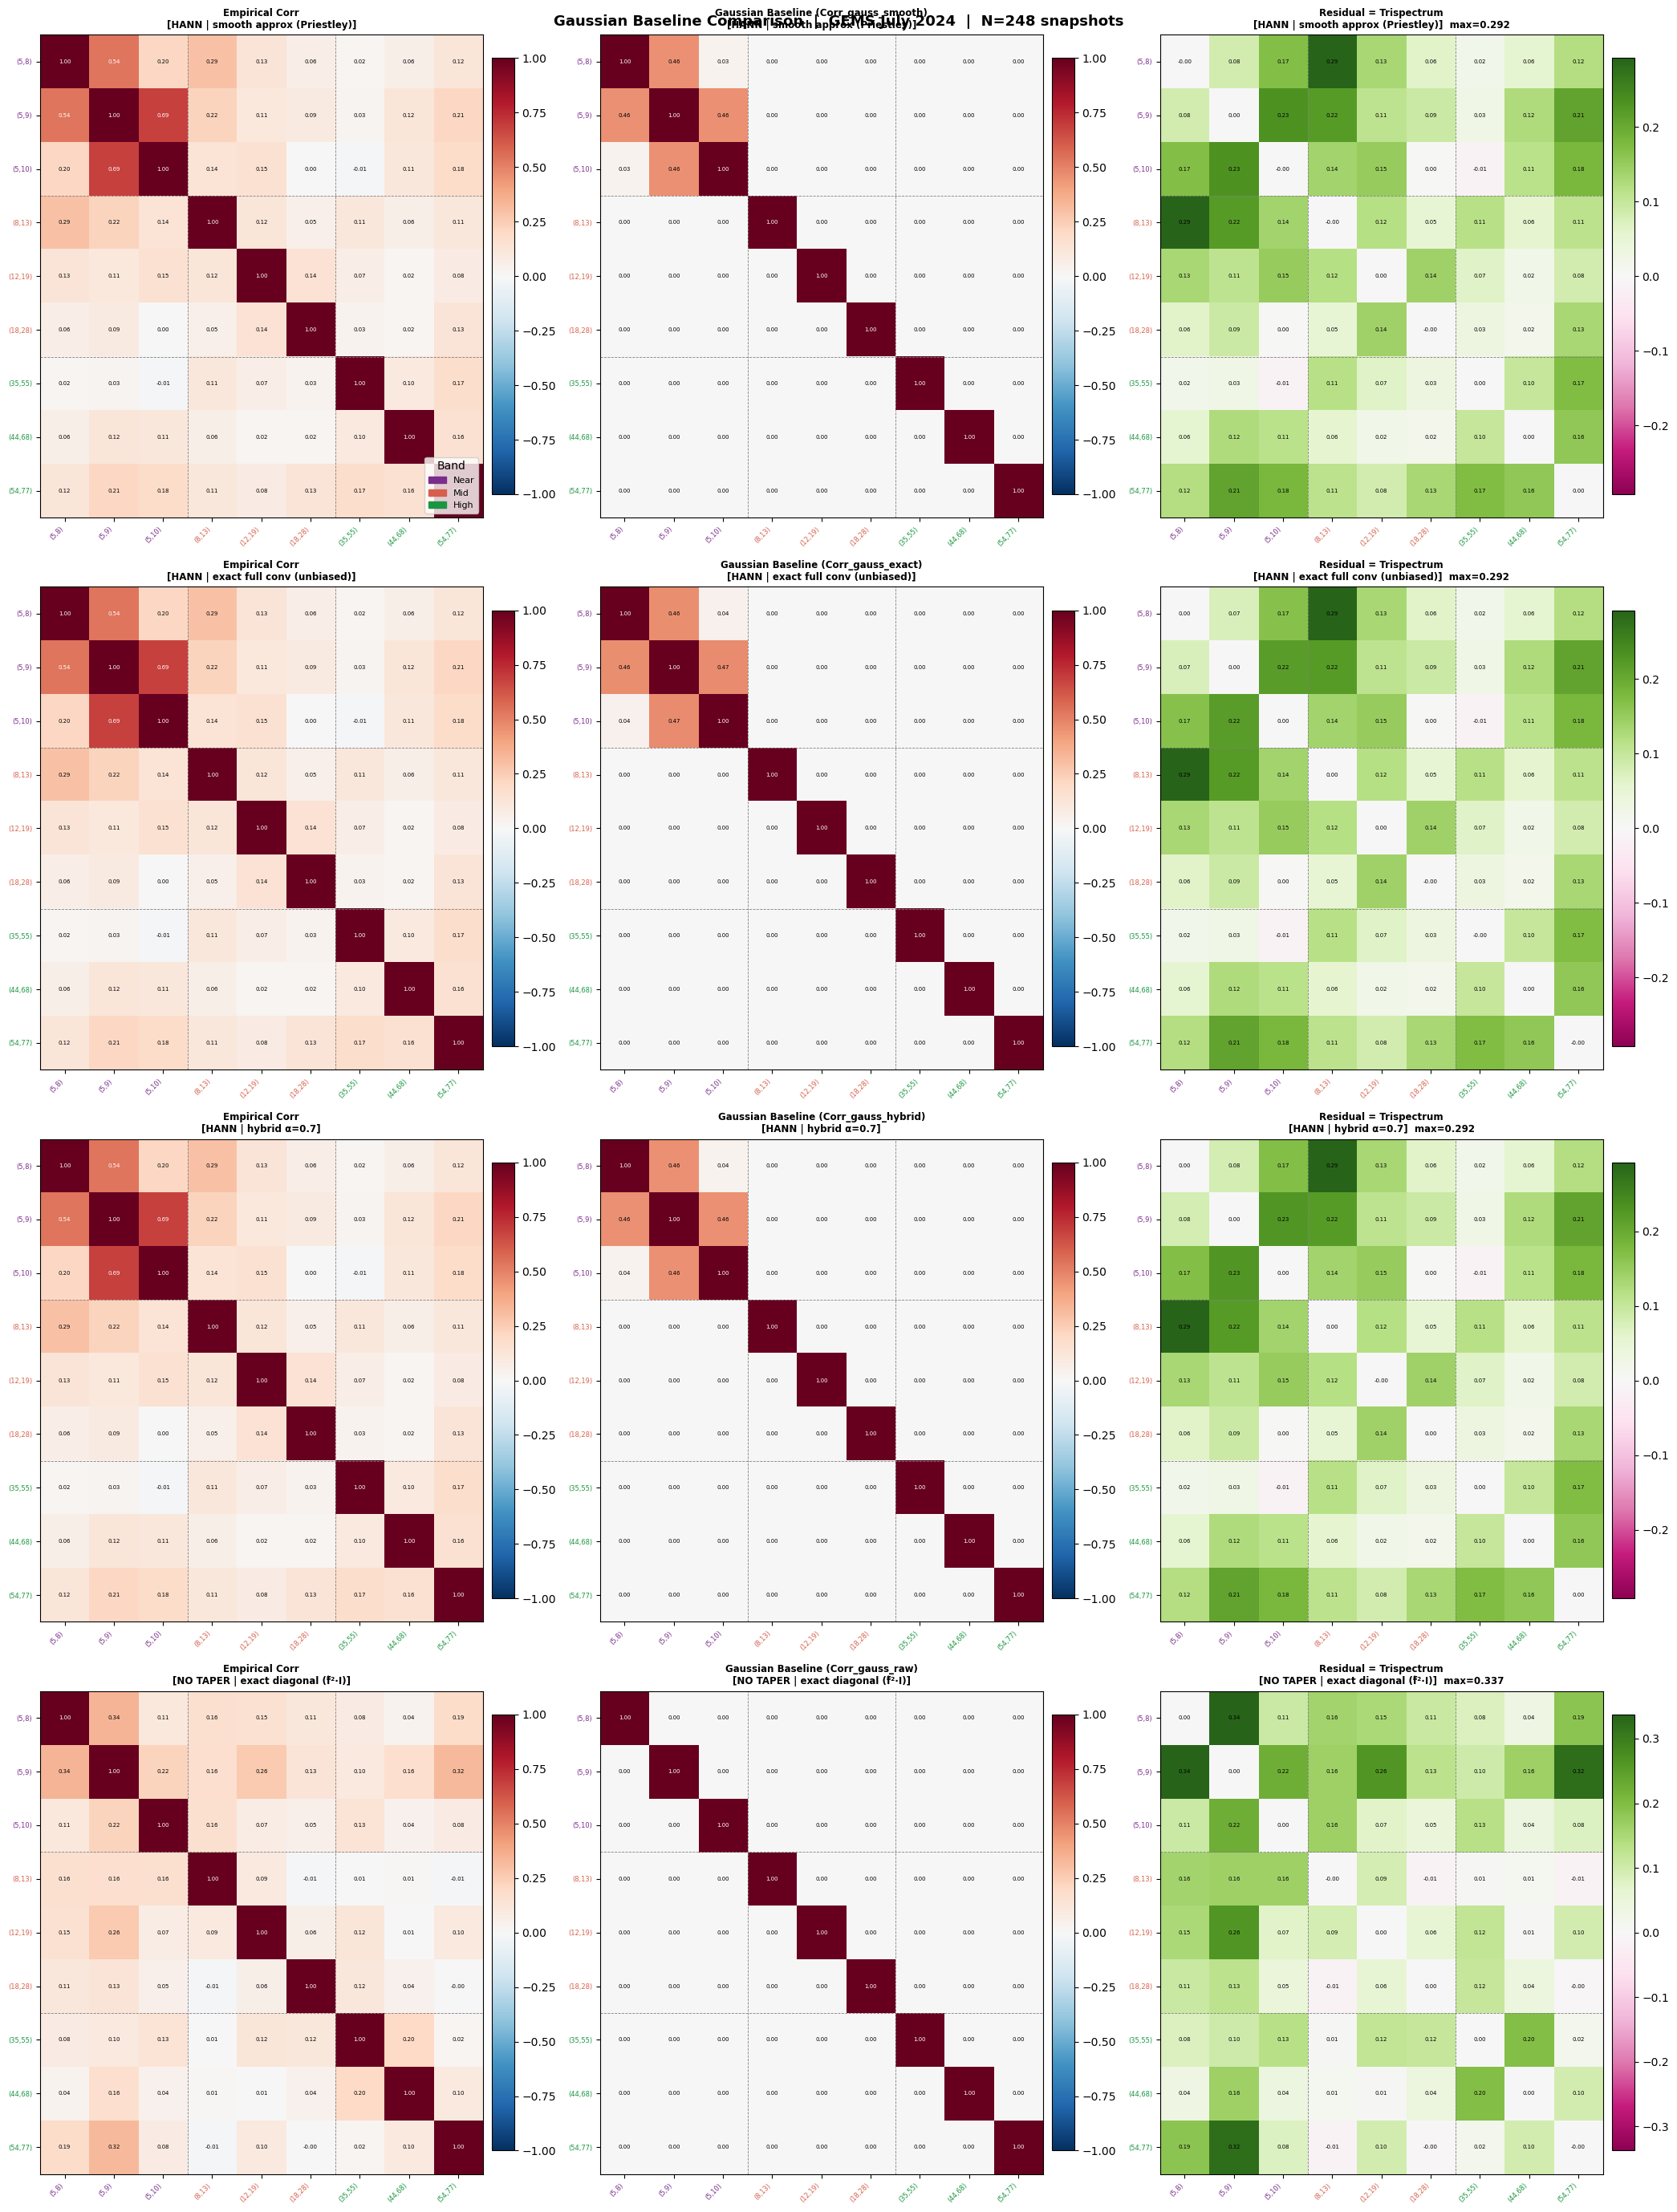

In [7]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Visualization: 4 × 3 grid
#   Each row:  Corr_emp  |  Corr_gauss  |  Residual (trispectrum estimate)
#   Row 1: HANN + smooth approx (Priestley, low-variance baseline)
#   Row 2: HANN + exact full conv (unbiased, high-variance baseline)
#   Row 3: HANN + hybrid (α=0.7)
#   Row 4: NO TAPER (exact diagonal baseline)
# ─────────────────────────────────────────────────────────────────────────────
band_colors_ = {"Near": "#7b2d8b", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels_ = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors_ = [band_colors_[b] for b in BAND_LABELS]
SEP_ = [2.5, 5.5]

def to_corr(cov):
    std = np.sqrt(np.clip(np.diag(cov), 1e-30, None))
    return cov / np.outer(std, std)

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels_, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(tick_labels_, fontsize=6)
    for q, tc in enumerate(tick_colors_):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP_:
        ax.axhline(sep, color='gray', lw=0.6, ls='--')
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5, color='white' if abs(mat[i,l]) > 0.5 else 'black')

# ── pre-compute correlation matrices ─────────────────────────────────────────
Cemp_tap    = to_corr(Cov_emp_tap)
Cgs_smooth  = to_corr(Cov_gauss_smooth)
Cgs_exact   = to_corr(Cov_gauss_exact)
Cgs_hybrid  = to_corr(Cov_gauss_hybrid)
Cemp_raw    = to_corr(Cov_emp_raw)
Cgs_raw     = np.eye(K)

rows = [
    (Cemp_tap, Cgs_smooth, "HANN | smooth approx (Priestley)",   "Corr_gauss_smooth"),
    (Cemp_tap, Cgs_exact,  "HANN | exact full conv (unbiased)",  "Corr_gauss_exact"),
    (Cemp_tap, Cgs_hybrid, f"HANN | hybrid α={ALPHA}",           "Corr_gauss_hybrid"),
    (Cemp_raw, Cgs_raw,    "NO TAPER | exact diagonal (f̂²·I)",  "Corr_gauss_raw"),
]

fig, axes = plt.subplots(4, 3, figsize=(21, 28))
fig.suptitle(
    f"Gaussian Baseline Comparison  |  GEMS July 2024  |  N={N_SNAP} snapshots",
    fontsize=13, fontweight='bold')

for row_idx, (Cemp, Cgauss, row_tag, gauss_name) in enumerate(rows):
    res = Cemp - Cgauss
    rlim = max(0.05, np.abs(res).max())
    draw_mat(axes[row_idx, 0], Cemp,   'RdBu_r', -1, 1,
             f"Empirical Corr\n[{row_tag}]")
    draw_mat(axes[row_idx, 1], Cgauss, 'RdBu_r', -1, 1,
             f"Gaussian Baseline ({gauss_name})\n[{row_tag}]")
    draw_mat(axes[row_idx, 2], res,    'PiYG', -rlim, rlim,
             f"Residual = Trispectrum\n[{row_tag}]  max={rlim:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors_.items()]
axes[0, 0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_gauss_comparison_4row.png', dpi=120, bbox_inches='tight')
plt.show()

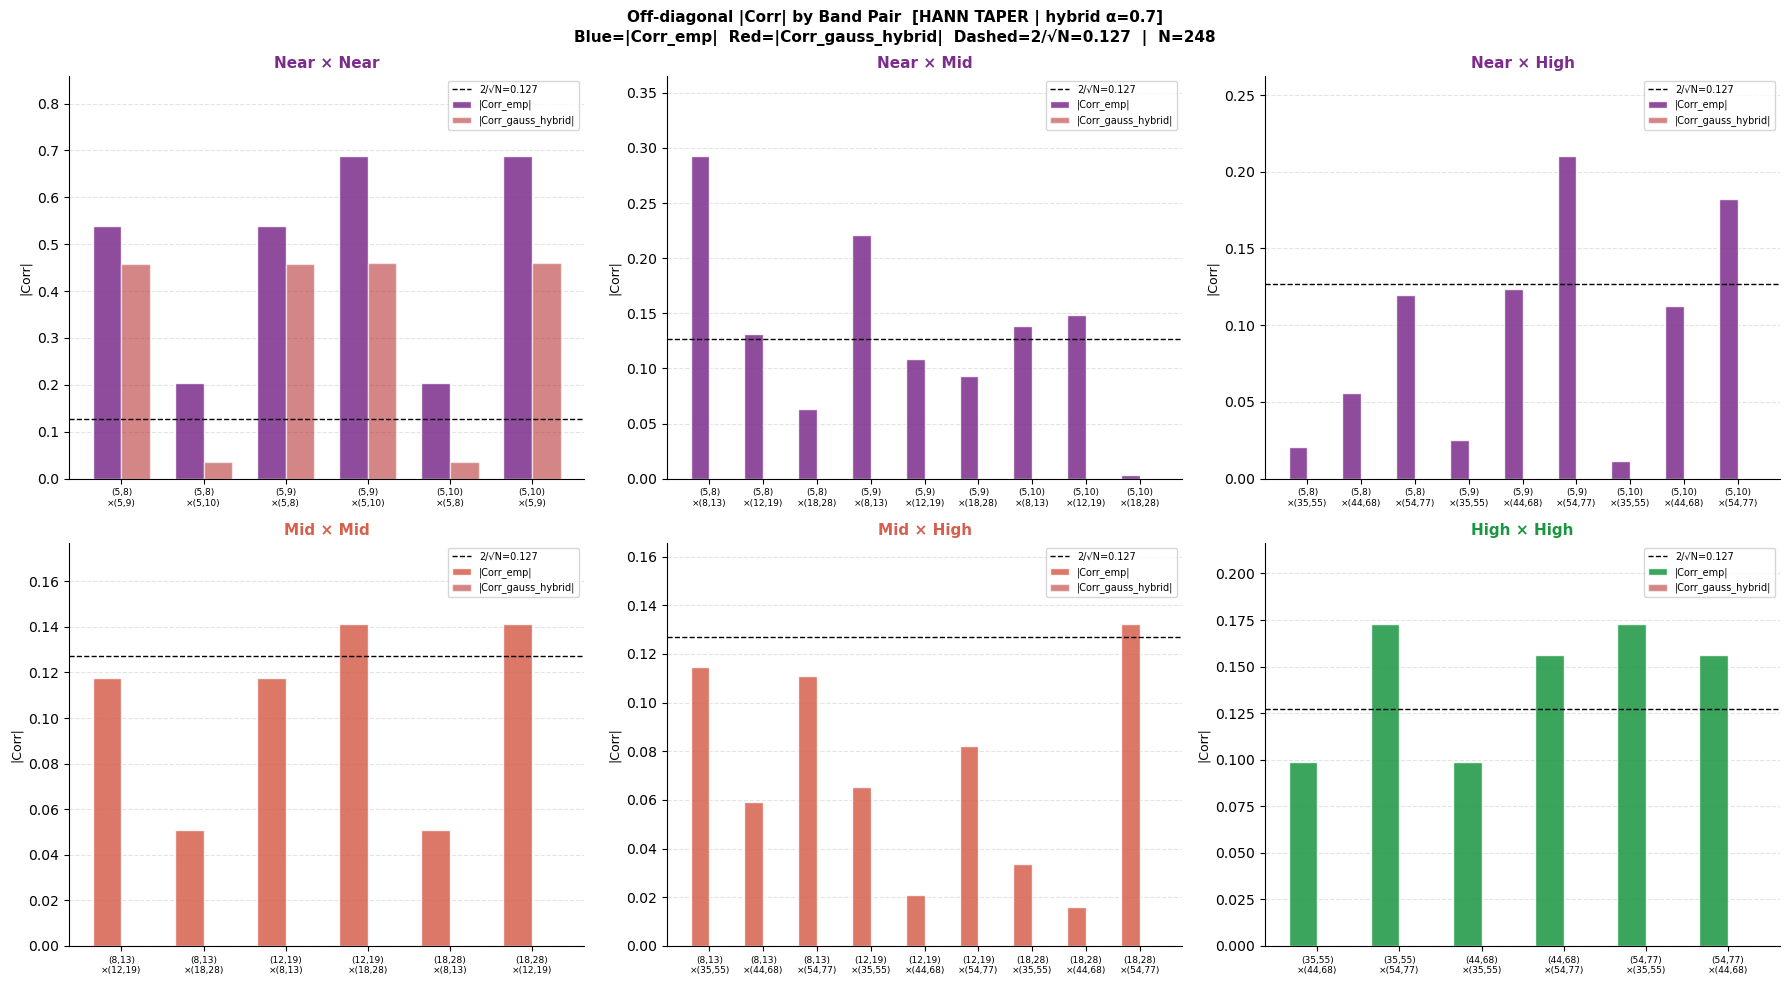


[HANN TAPER | hybrid α=0.7]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.6871        0.4596  6/6
  ⚠ Near ×Mid        0.2923        0.0000  5/9
  ⚠ Near ×High       0.2099        0.0000  2/9
  ⚠ Mid  ×Mid        0.1414        0.0000  2/6
  ⚠ Mid  ×High       0.1324        0.0000  1/9
  ⚠ High ×High       0.1730        0.0000  4/6


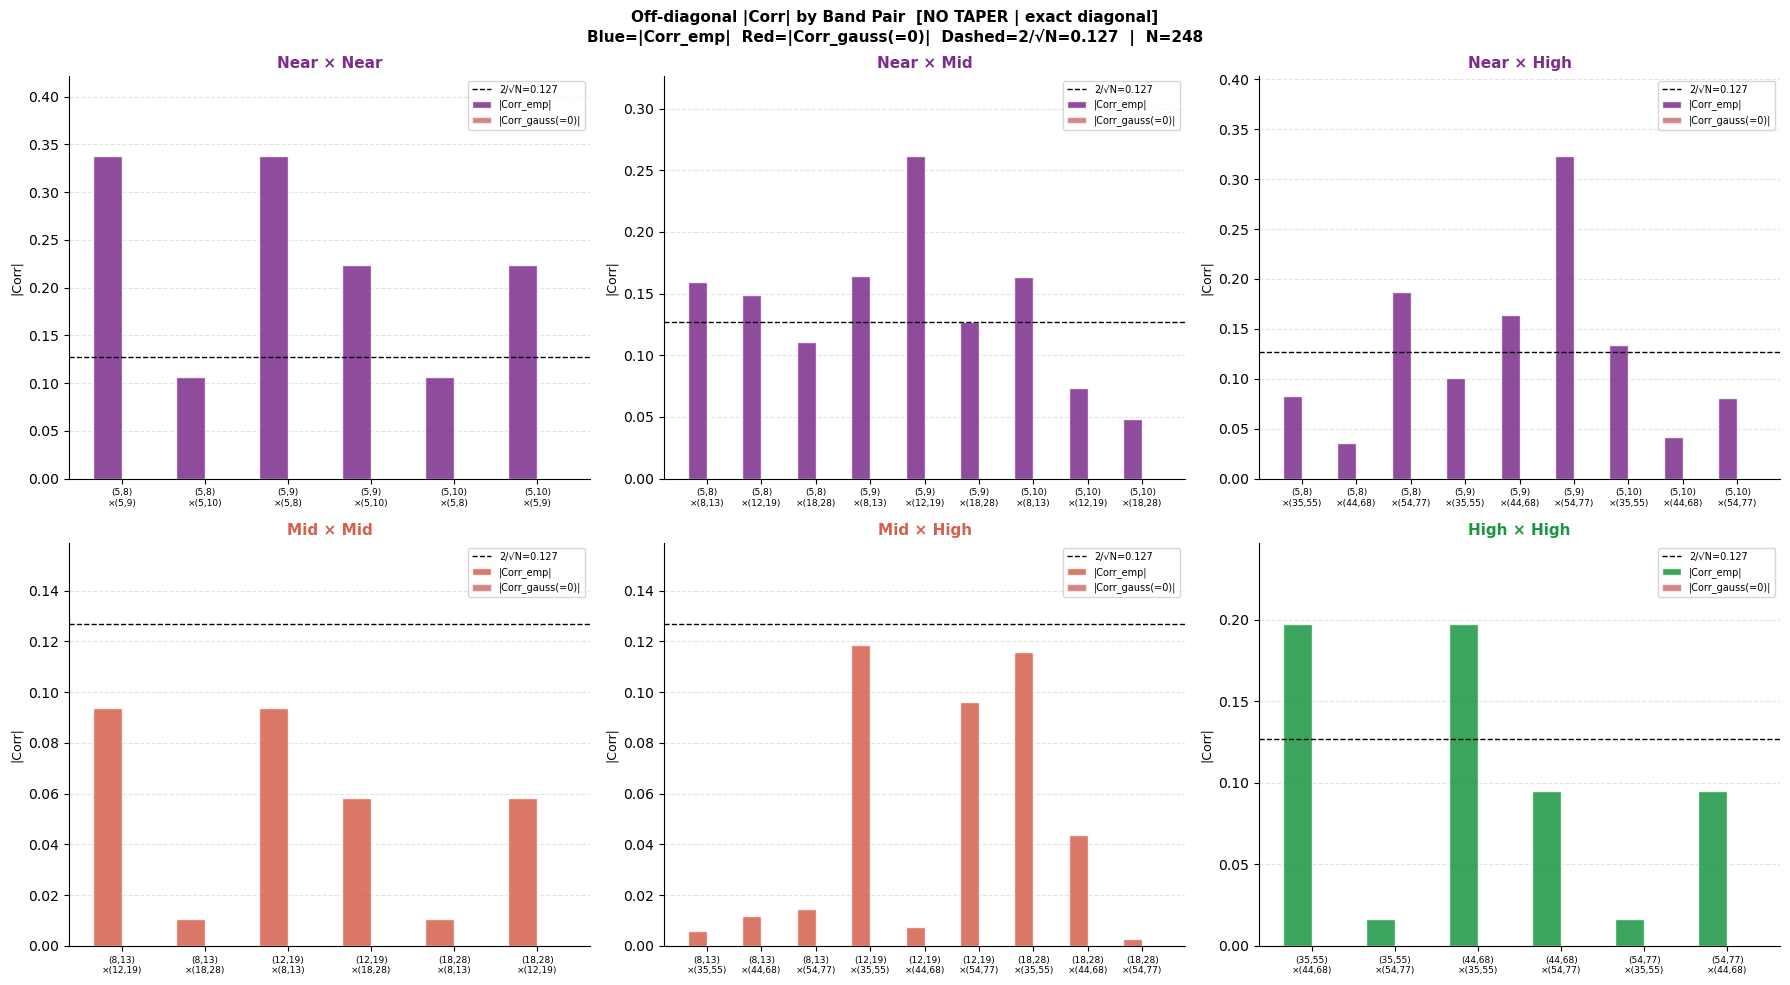


[NO TAPER | exact diagonal]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.3372        0.0000  4/6
  ⚠ Near ×Mid        0.2612        0.0000  5/9
  ⚠ Near ×High       0.3227        0.0000  4/9
    Mid  ×Mid        0.0938        0.0000  0/6
    Mid  ×High       0.1187        0.0000  0/9
  ⚠ High ×High       0.1976        0.0000  2/6


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic — Off-diagonal |Corr| by band pair
#   Uses variables defined in visualization cell above:
#     Cemp_tap / Cgs_hybrid  for taper version (hybrid baseline)
#     Cemp_raw / Cgs_raw     for no-taper version
# ─────────────────────────────────────────────────────────────────────────────
BANDS_IDX = {
    b: [i for i, bl in enumerate(BAND_LABELS) if bl == b]
    for b in ["Near", "Mid", "High"]
}
BAND_PAIRS = [("Near","Near"),("Near","Mid"),("Near","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_SNAP)

def diag_offdiag(Corr_emp, Corr_gauss, title_tag, gauss_label):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        f"Off-diagonal |Corr| by Band Pair  [{title_tag}]\n"
        f"Blue=|Corr_emp|  Red=|{gauss_label}|  "
        f"Dashed=2/√N={sig_thresh:.3f}  |  N={N_SNAP}",
        fontsize=11, fontweight='bold')
    axes = axes.ravel()
    summary = []
    for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
        ax = axes[ax_idx]
        pe, pg, lbls = [], [], []
        for i in BANDS_IDX[b1]:
            for l in BANDS_IDX[b2]:
                if b1 == b2 and i == l:
                    continue
                pe.append(abs(Corr_emp[i, l]))
                pg.append(abs(Corr_gauss[i, l]))
                lbls.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")
        x = np.arange(len(pe)); w = 0.35
        ax.bar(x-w/2, pe, w, color=band_colors_.get(b1, "#555555"), alpha=0.85, edgecolor='w', label='|Corr_emp|')
        ax.bar(x+w/2, pg, w, color='firebrick',       alpha=0.55, edgecolor='w', label=f'|{gauss_label}|')
        ax.axhline(sig_thresh, color='k', ls='--', lw=1.0, label=f'2/√N={sig_thresh:.3f}')
        ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors_.get(b1, "#555555"))
        ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=6.5)
        ax.set_ylabel("|Corr|", fontsize=9)
        ax.set_ylim(0, max(0.05, max(pe + pg + [sig_thresh]) * 1.25))
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)
        summary.append((b1, b2, max(pe), max(pg), sum(v > sig_thresh for v in pe), len(pe)))
    plt.tight_layout()
    plt.savefig(f'/tmp/offdiag_{title_tag.lower().replace(" ","_")}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n[{title_tag}]  sig threshold = {sig_thresh:.4f}")
    print(f"{'Pair':>14}  {'max|emp|':>10}  {'max|gauss|':>12}  {'n_sig/n':>10}")
    print("-"*55)
    for b1_, b2_, me, mg, ns, np_ in summary:
        flag = "⚠" if me > sig_thresh else " "
        print(f"  {flag} {b1_:5s}×{b2_:5s}  {me:10.4f}  {mg:12.4f}  {ns}/{np_}")

# Taper: use hybrid baseline (α=0.7 shrinkage, best for physical detection)
diag_offdiag(Cemp_tap, Cgs_hybrid, f"HANN TAPER | hybrid α={ALPHA}", "Corr_gauss_hybrid")
# No-taper: use exact identity baseline
diag_offdiag(Cemp_raw, Cgs_raw,    "NO TAPER | exact diagonal",      "Corr_gauss(=0)")

## First-Difference Filter Analysis (2-1-1-0)

Debiased Whittle likelihood works on the **filtered field**:

$$Z(i,j) = -2\,X(i,j) + X(i+1,j) + X(i,j+1)$$

with spatial weights $\{(0,0){:}{-2},\,(1,0){:}{+1},\,(0,1){:}{+1}\}$ — same kernel as in `debiased_whittle_2110.py`.

**Why filter first?**  
- Raw field: spectral density drops $\sim 4$ orders of magnitude from Low to High band ($\hat{f} \approx 4000 \to 2$)  
- After 2-1-1-0: spectral shape flatter → smooth approx bias reduced, Gaussian baseline more accurate  
- Grid shrinks: $(M,N)=(114,159) \to (113,158)$

**Questions checked below:**  
1. Does empirical off-diagonal correlation change after filtering?  
2. Does the gap between `Cov_emp` and `Cov_gauss_exact` close?

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# ─────────────────────────────────────────────────────────────────────────────
# Filter setup
#   Z(i,j) = -2·X(i,j) + X(i+1,j) + X(i,j+1)
#   Grid: (M_grid, N_grid) = (114, 159) → (M_d, N_d) = (113, 158)
#   obs_d[i,j] = 1  iff  all three contributing cells were observed
# ─────────────────────────────────────────────────────────────────────────────
M_d = M_grid - 1   # 113
N_d = N_grid - 1   # 158

h_d = np.outer(np.hanning(M_d), np.hanning(N_d))   # unnormalized Hann

MN_d    = M_d * N_d
scale_raw_d = np.sqrt(MN_d)

for (j1, j2) in FREQ_ALL:
    assert j1 < M_d // 2 and j2 < N_d // 2, f"freq {(j1,j2)} out of range for ({M_d},{N_d})"

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Collect snapshots on FILTERED field (same H_q convention)
# ─────────────────────────────────────────────────────────────────────────────
N_SNAP = N_DAYS * 8
J_tap_d  = np.zeros((N_SNAP, K), dtype=complex)
J_raw_d  = np.zeros((N_SNAP, K), dtype=complex)
f_full_d = np.zeros((M_d, N_d), dtype=float)
g_eff_sum_d = np.zeros((M_d, N_d), dtype=float)
H_q_list_d  = []

print(f"Filtered grid: {M_d}×{N_d}")
print(f"Extracting DFT coefficients (filtered): {N_SNAP} snapshots × {K} frequencies ...")
idx = 0
for d in range(N_DAYS):
    keys = sorted(daily_hourly_maps[d].keys())
    for key in keys[:8]:
        t_s  = daily_hourly_maps[d][key]
        raw  = t_s[:, 2].numpy().reshape(M_grid, N_grid)
        obs_full = np.isfinite(raw).astype(float)

        # obs mask for filtered grid: all 3 contributing cells must be observed
        obs_d_s = obs_full[:-1, :-1] * obs_full[1:, :-1] * obs_full[:-1, 1:]

        field_mean = np.nanmean(raw)
        field = np.nan_to_num(raw - field_mean, nan=0.0)

        # 2-1-1-0 first-difference filter
        g_d = -2.0 * field[:-1, :-1] + field[1:, :-1] + field[:-1, 1:]

        g_eff_d = h_d * obs_d_s
        H_q_d   = float(np.sum(g_eff_d**2))
        norm_q_d = 1.0 / (2.0 * np.pi * np.sqrt(H_q_d))

        F_tap_d = fftn(g_eff_d * g_d)
        F_raw_d = fftn(g_d)

        f_full_d  += np.abs(F_tap_d * norm_q_d)**2
        g_eff_sum_d += g_eff_d
        H_q_list_d.append(H_q_d)

        for q, (j1, j2) in enumerate(FREQ_ALL):
            J_tap_d[idx, q] = F_tap_d[j1, j2] * norm_q_d
            J_raw_d[idx, q] = F_raw_d[j1, j2] / scale_raw_d
        idx += 1

f_full_d /= N_SNAP

g_eff_mean_d = g_eff_sum_d / N_SNAP
H_q_mean_d   = float(np.mean(H_q_list_d))
W_g2_mean_d  = fftn(g_eff_mean_d**2)
g_dft_mean_d = fftn(g_eff_mean_d)

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Periodogram + empirical covariance
# ─────────────────────────────────────────────────────────────────────────────
I_tap_d = np.abs(J_tap_d)**2
I_raw_d = np.abs(J_raw_d)**2
f_hat_tap_d = I_tap_d.mean(axis=0)
f_hat_raw_d = I_raw_d.mean(axis=0)

def emp_cov(I):
    Ic = I - I.mean(axis=0)
    return (Ic.T @ Ic) / I.shape[0]

Cov_emp_tap_d = emp_cov(I_tap_d)
Cov_emp_raw_d = emp_cov(I_raw_d)

# ─────────────────────────────────────────────────────────────────────────────
# Step 3a: Smooth Wick baseline (filtered grid)
# ─────────────────────────────────────────────────────────────────────────────
Cov_gauss_smooth_d = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    for l, (k1, k2) in enumerate(FREQ_ALL):
        dm = ((j1-k1) % M_d, (j2-k2) % N_d)
        dp = ((j1+k1) % M_d, (j2+k2) % N_d)
        Cov_gauss_smooth_d[i, l] = (
            f_hat_tap_d[i] * f_hat_tap_d[l]
            * (abs(W_g2_mean_d[dm])**2 + abs(W_g2_mean_d[dp])**2)
            / H_q_mean_d**2
        )

# ─────────────────────────────────────────────────────────────────────────────
# Step 3b: Exact Wick baseline (filtered grid)
# ─────────────────────────────────────────────────────────────────────────────
m1_d = np.arange(M_d)[:, None]
m2_d = np.arange(N_d)[None, :]

print("Computing exact Gaussian covariance (filtered field) ...")
Cov_gauss_exact_d = np.zeros((K, K), dtype=float)
for i, (j1, j2) in enumerate(FREQ_ALL):
    g_j_d = g_dft_mean_d[(j1 - m1_d) % M_d, (j2 - m2_d) % N_d]
    for l, (k1, k2) in enumerate(FREQ_ALL):
        g_k_conj_d = np.conj(g_dft_mean_d[(k1 - m1_d) % M_d, (k2 - m2_d) % N_d])
        g_k_pos_d  = g_dft_mean_d[(k1 + m1_d) % M_d, (k2 + m2_d) % N_d]
        S_jk = np.sum(f_full_d * g_j_d * g_k_conj_d) / (H_q_mean_d * MN_d)
        P_jk = np.sum(f_full_d * g_j_d * g_k_pos_d)  / (H_q_mean_d * MN_d)
        Cov_gauss_exact_d[i, l] = abs(S_jk)**2 + abs(P_jk)**2

Cov_gauss_hybrid_d = ALPHA * Cov_gauss_smooth_d + (1 - ALPHA) * Cov_gauss_exact_d
Cov_gauss_raw_d    = np.diag(f_hat_raw_d**2)

Cov_ng_smooth_d = Cov_emp_tap_d - Cov_gauss_smooth_d
Cov_ng_exact_d  = Cov_emp_tap_d - Cov_gauss_exact_d
Cov_ng_hybrid_d = Cov_emp_tap_d - Cov_gauss_hybrid_d
Cov_ng_raw_d    = Cov_emp_raw_d - Cov_gauss_raw_d

# ─────────────────────────────────────────────────────────────────────────────
# Summary: raw vs filtered spectral density + variance ratios
# ─────────────────────────────────────────────────────────────────────────────
print(f"H_q_mean_d = {H_q_mean_d:.2f}  |  full-grid H_q_d = {np.sum(h_d**2):.2f}")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_raw':>12}  {'f̂_filt':>12}  "
      f"{'ratio':>7}  {'Var_emp_raw':>13}  {'Var_emp_filt':>14}")
print("-"*95)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    r = f_hat_tap_d[q] / f_hat_tap[q] if f_hat_tap[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat_tap[q]:12.6f}  {f_hat_tap_d[q]:12.6f}  {r:7.4f}  "
          f"{Cov_emp_tap[q,q]:13.4e}  {Cov_emp_tap_d[q,q]:14.4e}")

Filtered grid: 113×158
Extracting DFT coefficients (filtered): 248 snapshots × 9 frequencies ...
Computing exact Gaussian covariance (filtered field) ...
H_q_mean_d = 2388.62  |  full-grid H_q_d = 2472.75

  q   Band          freq        f̂_raw       f̂_filt    ratio    Var_emp_raw    Var_emp_filt
-----------------------------------------------------------------------------------------------
   0  Near   (  5,  8)      1.148119      0.398297   0.3469     2.2171e+00      2.9072e-01
   1  Near   (  5,  9)      1.202457      0.439048   0.3651     3.1494e+00      4.0044e-01
   2  Near   (  5, 10)      0.990443      0.393208   0.3970     1.7052e+00      2.4408e-01
   3  Mid    (  8, 13)      0.578750      0.495496   0.8561     5.2704e-01      3.6978e-01
   4  Mid    ( 12, 19)      0.281301      0.533939   1.8981     1.6040e-01      5.8461e-01
   5  Mid    ( 18, 28)      0.118907      0.455102   3.8274     1.6375e-02      2.7021e-01
   6  High   ( 35, 55)      0.051009      0.608042  11.9204

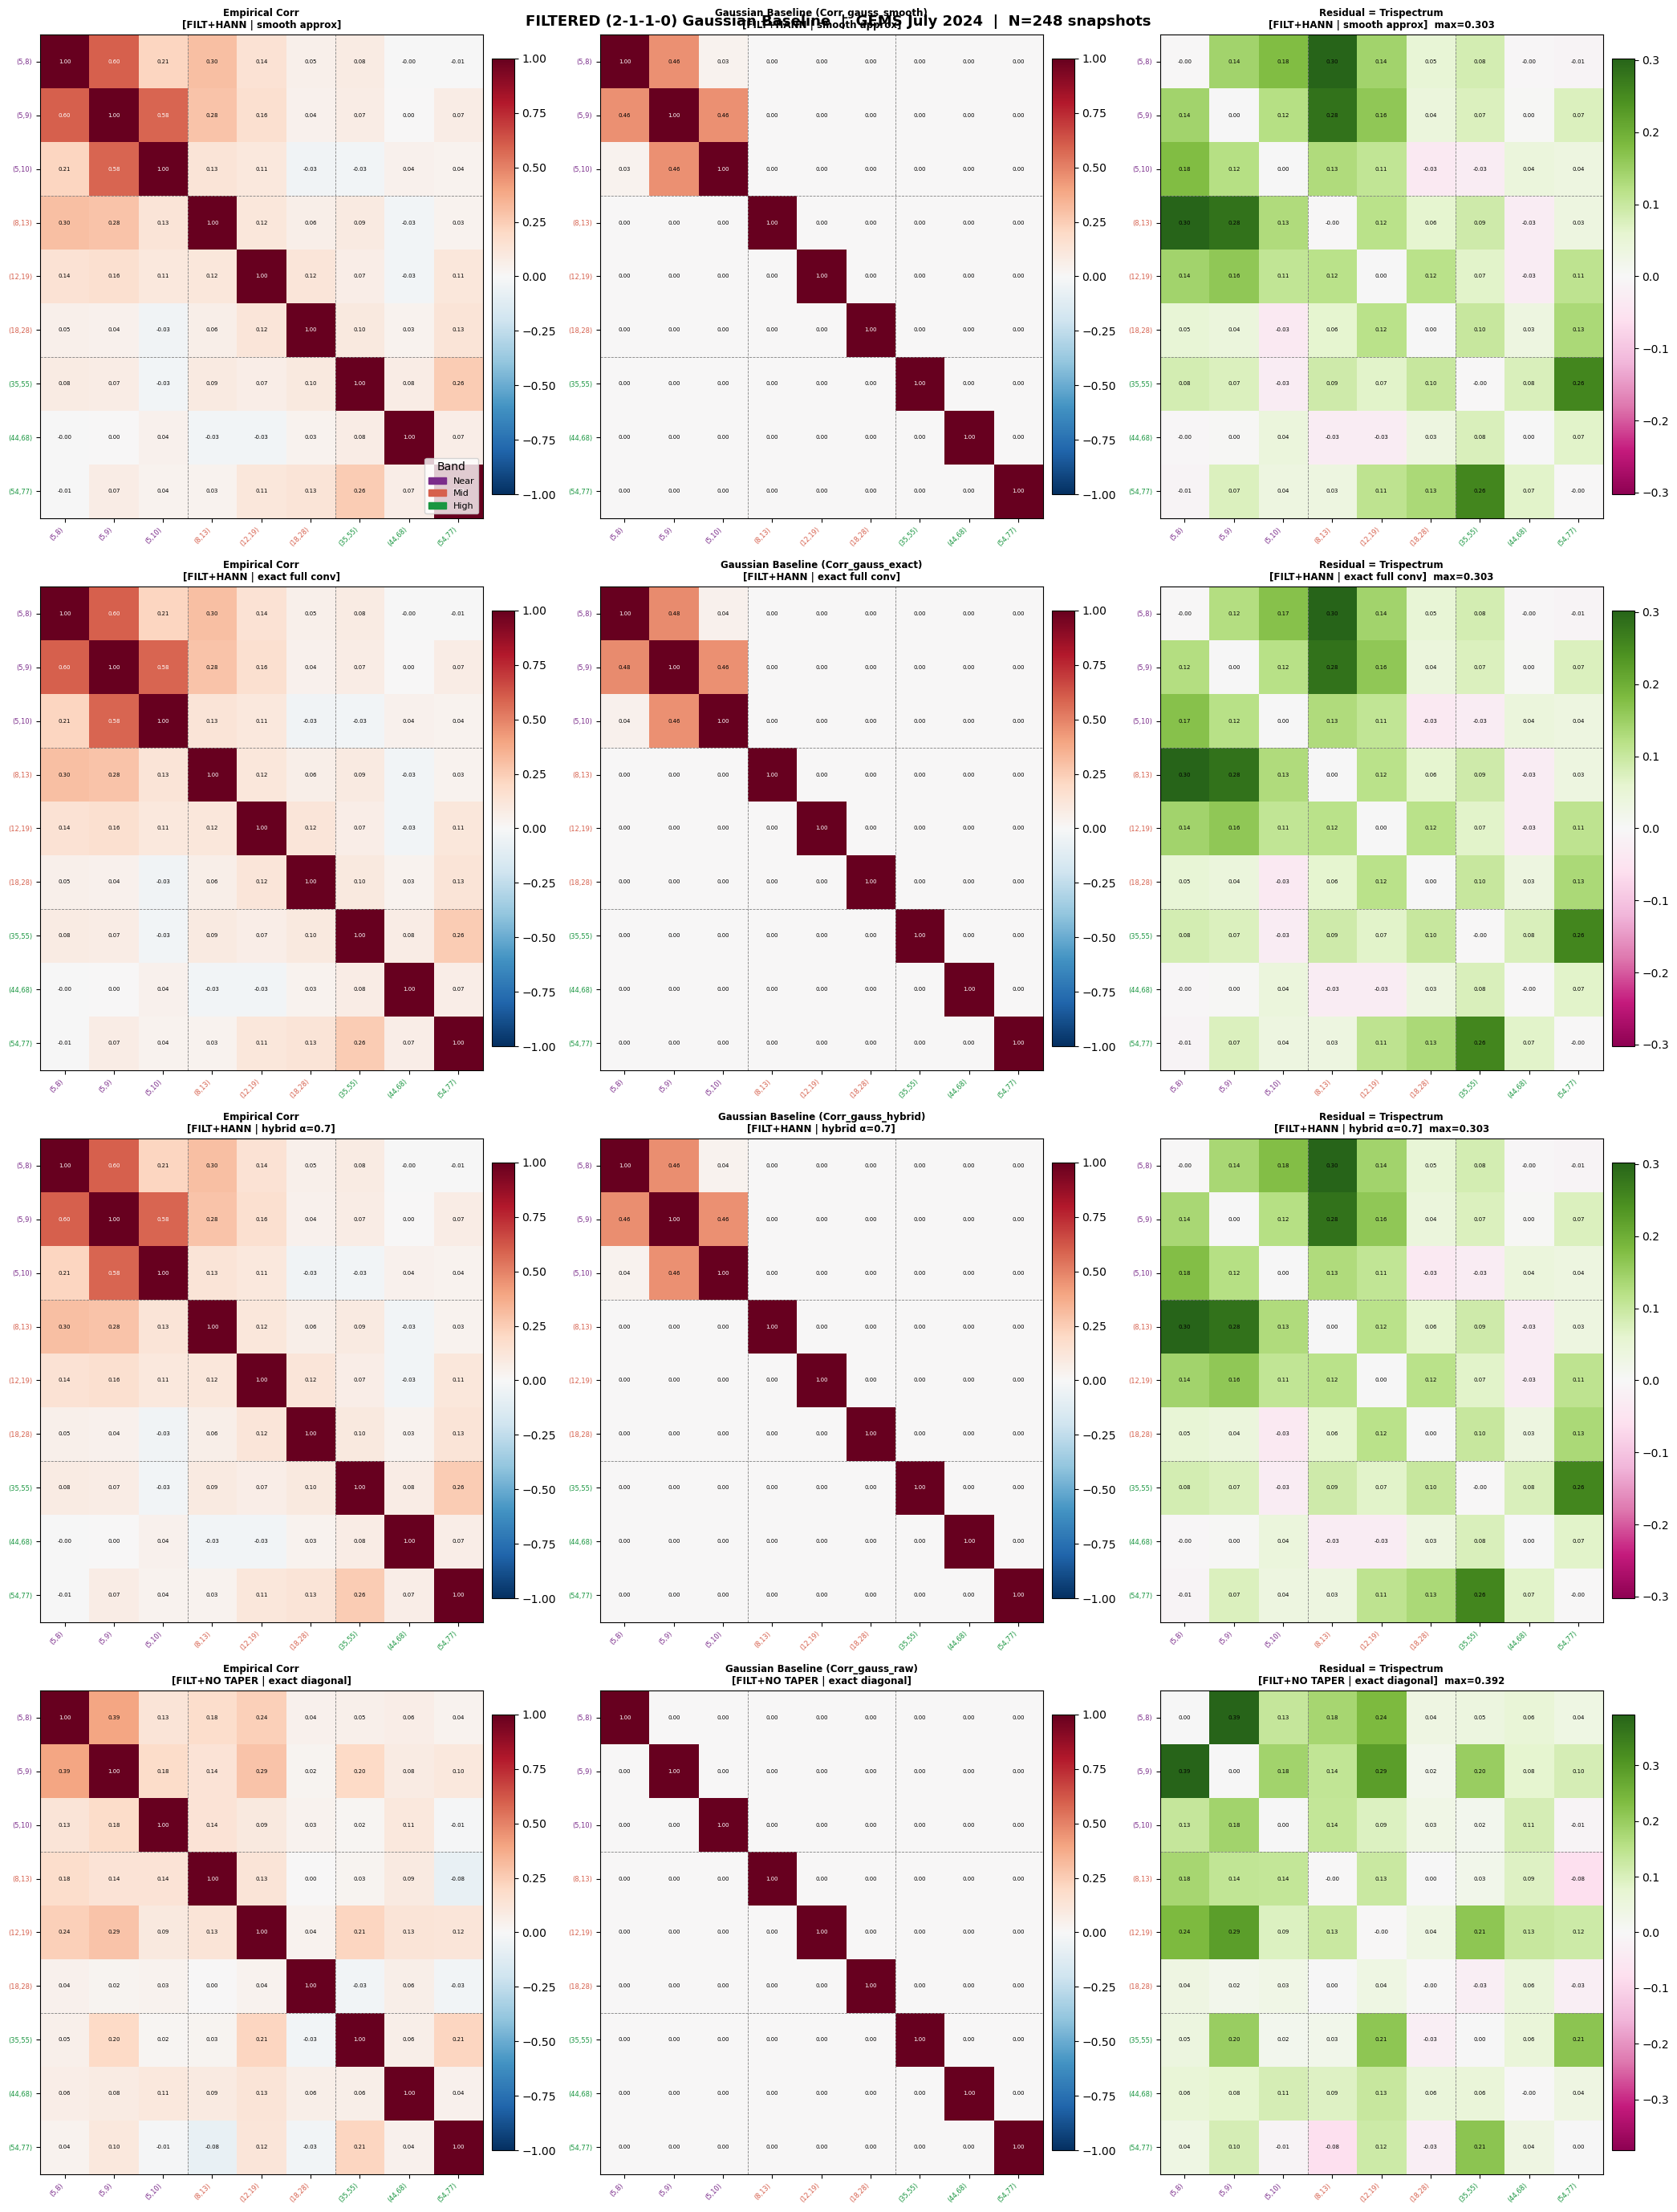

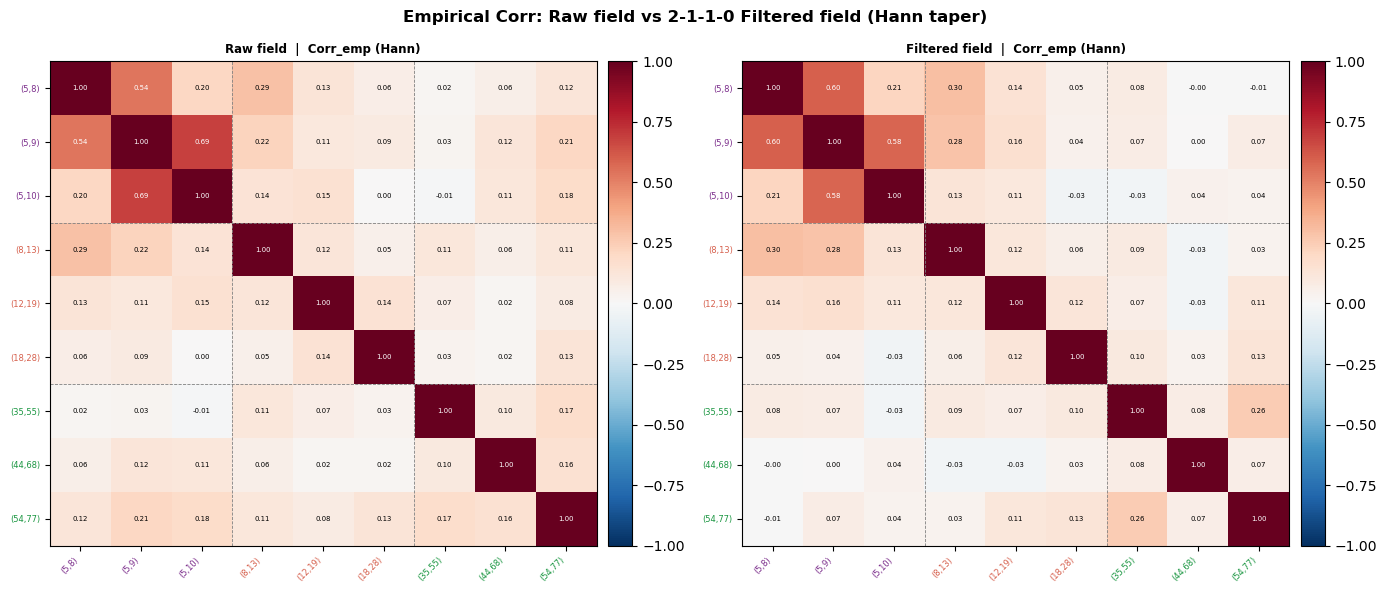

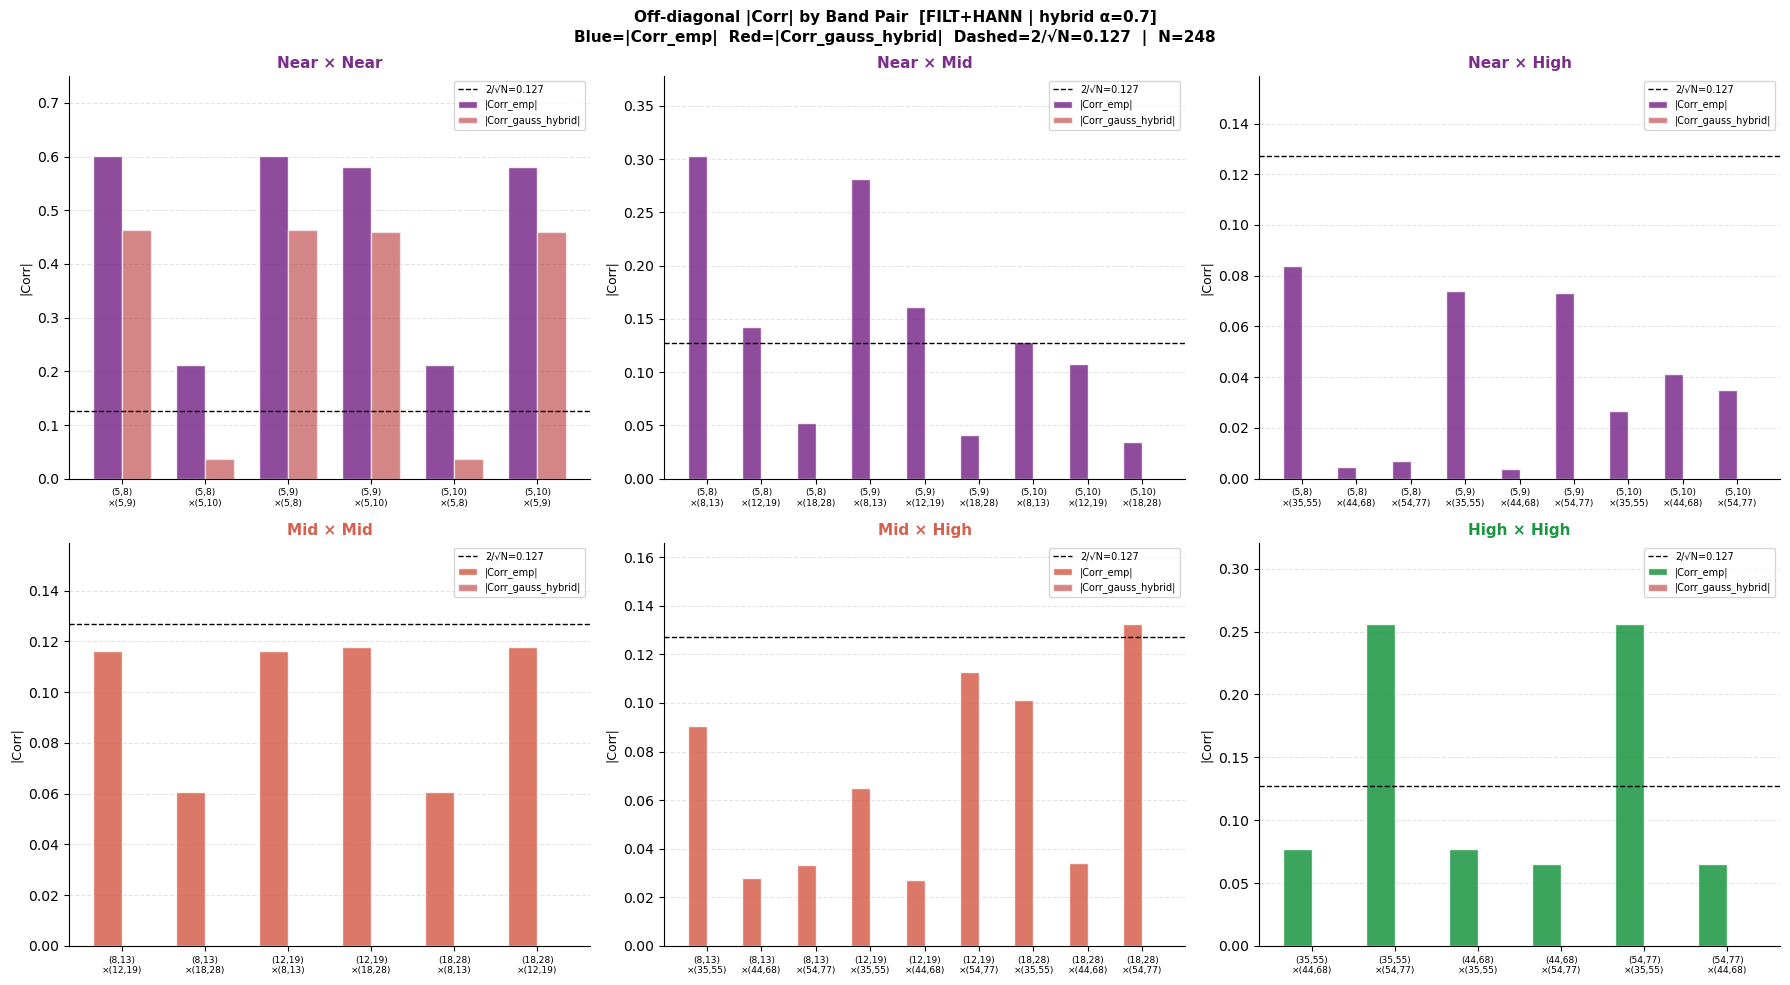


[FILT+HANN | hybrid α=0.7]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.6003        0.4637  6/6
  ⚠ Near ×Mid        0.3025        0.0000  5/9
    Near ×High       0.0838        0.0000  0/9
    Mid  ×Mid        0.1178        0.0000  0/6
  ⚠ Mid  ×High       0.1326        0.0000  1/9
  ⚠ High ×High       0.2562        0.0000  2/6


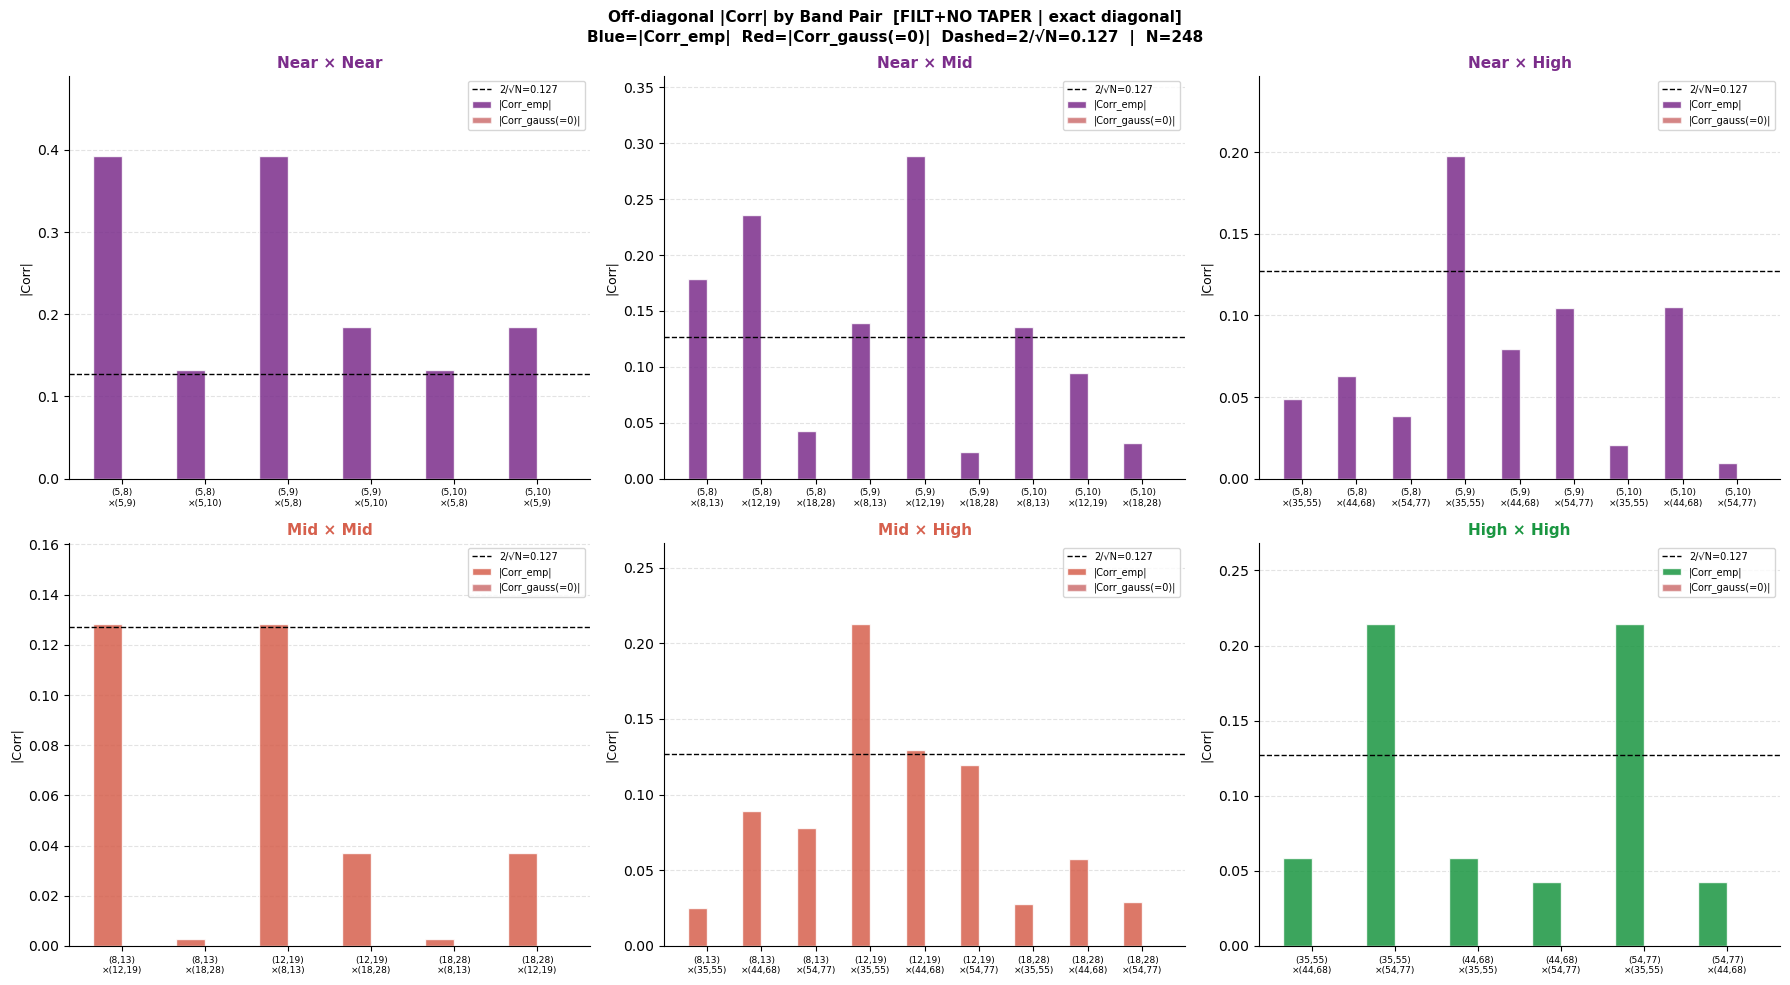


[FILT+NO TAPER | exact diagonal]  sig threshold = 0.1270
          Pair    max|emp|    max|gauss|     n_sig/n
-------------------------------------------------------
  ⚠ Near ×Near       0.3919        0.0000  6/6
  ⚠ Near ×Mid        0.2882        0.0000  5/9
  ⚠ Near ×High       0.1973        0.0000  1/9
  ⚠ Mid  ×Mid        0.1284        0.0000  2/6
  ⚠ Mid  ×High       0.2130        0.0000  2/9
  ⚠ High ×High       0.2146        0.0000  2/6


In [10]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Visualization: filtered field — same 4-row layout as before
# ─────────────────────────────────────────────────────────────────────────────
band_colors_ = {"Near": "#7b2d8b", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels_ = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors_ = [band_colors_[b] for b in BAND_LABELS]
SEP_ = [2.5, 5.5]

def to_corr(cov):
    std = np.sqrt(np.clip(np.diag(cov), 1e-30, None))
    return cov / np.outer(std, std)

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=8.5, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels_, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(tick_labels_, fontsize=6)
    for q, tc in enumerate(tick_colors_):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP_:
        ax.axhline(sep, color='gray', lw=0.6, ls='--')
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5, color='white' if abs(mat[i,l]) > 0.5 else 'black')

Cemp_tap_d   = to_corr(Cov_emp_tap_d)
Cgs_smooth_d = to_corr(Cov_gauss_smooth_d)
Cgs_exact_d  = to_corr(Cov_gauss_exact_d)
Cgs_hybrid_d = to_corr(Cov_gauss_hybrid_d)
Cemp_raw_d   = to_corr(Cov_emp_raw_d)
Cgs_raw_d    = np.eye(K)

rows_d = [
    (Cemp_tap_d, Cgs_smooth_d, "FILT+HANN | smooth approx",        "Corr_gauss_smooth"),
    (Cemp_tap_d, Cgs_exact_d,  "FILT+HANN | exact full conv",       "Corr_gauss_exact"),
    (Cemp_tap_d, Cgs_hybrid_d, f"FILT+HANN | hybrid α={ALPHA}",     "Corr_gauss_hybrid"),
    (Cemp_raw_d, Cgs_raw_d,    "FILT+NO TAPER | exact diagonal",    "Corr_gauss_raw"),
]

fig, axes = plt.subplots(4, 3, figsize=(21, 28))
fig.suptitle(
    f"FILTERED (2-1-1-0) Gaussian Baseline  |  GEMS July 2024  |  N={N_SNAP} snapshots",
    fontsize=13, fontweight='bold')

for row_idx, (Cemp, Cgauss, row_tag, gauss_name) in enumerate(rows_d):
    res = Cemp - Cgauss
    rlim = max(0.05, np.abs(res).max())
    draw_mat(axes[row_idx, 0], Cemp,   'RdBu_r', -1, 1,
             f"Empirical Corr\n[{row_tag}]")
    draw_mat(axes[row_idx, 1], Cgauss, 'RdBu_r', -1, 1,
             f"Gaussian Baseline ({gauss_name})\n[{row_tag}]")
    draw_mat(axes[row_idx, 2], res,    'PiYG', -rlim, rlim,
             f"Residual = Trispectrum\n[{row_tag}]  max={rlim:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors_.items()]
axes[0, 0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')
plt.tight_layout()
plt.savefig('/tmp/cov_gauss_filtered_4row.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Side-by-side: RAW vs FILTERED empirical correlation
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Empirical Corr: Raw field vs 2-1-1-0 Filtered field (Hann taper)",
              fontsize=12, fontweight='bold')
draw_mat(axes2[0], to_corr(Cov_emp_tap),   'RdBu_r', -1, 1, "Raw field  |  Corr_emp (Hann)")
draw_mat(axes2[1], Cemp_tap_d,             'RdBu_r', -1, 1, "Filtered field  |  Corr_emp (Hann)")
plt.tight_layout()
plt.savefig('/tmp/cov_emp_raw_vs_filtered.png', dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Off-diagonal diagnostic: filtered hybrid baseline
# ─────────────────────────────────────────────────────────────────────────────
BANDS_IDX = {b: [i for i, bl in enumerate(BAND_LABELS) if bl == b]
             for b in ["Near", "Mid", "High"]}
BAND_PAIRS = [("Near","Near"),("Near","Mid"),("Near","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_SNAP)

def diag_offdiag(Corr_emp, Corr_gauss, title_tag, gauss_label):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        f"Off-diagonal |Corr| by Band Pair  [{title_tag}]\n"
        f"Blue=|Corr_emp|  Red=|{gauss_label}|  "
        f"Dashed=2/√N={sig_thresh:.3f}  |  N={N_SNAP}",
        fontsize=11, fontweight='bold')
    axes = axes.ravel()
    summary = []
    for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
        ax = axes[ax_idx]
        pe, pg, lbls = [], [], []
        for i in BANDS_IDX[b1]:
            for l in BANDS_IDX[b2]:
                if b1 == b2 and i == l:
                    continue
                pe.append(abs(Corr_emp[i, l]))
                pg.append(abs(Corr_gauss[i, l]))
                lbls.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")
        x = np.arange(len(pe)); w = 0.35
        ax.bar(x-w/2, pe, w, color=band_colors_.get(b1, "#555555"), alpha=0.85, edgecolor='w', label='|Corr_emp|')
        ax.bar(x+w/2, pg, w, color='firebrick',       alpha=0.55, edgecolor='w', label=f'|{gauss_label}|')
        ax.axhline(sig_thresh, color='k', ls='--', lw=1.0, label=f'2/√N={sig_thresh:.3f}')
        ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors_.get(b1, "#555555"))
        ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=6.5)
        ax.set_ylabel("|Corr|", fontsize=9)
        ax.set_ylim(0, max(0.05, max(pe + pg + [sig_thresh]) * 1.25))
        ax.legend(fontsize=7)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)
        summary.append((b1, b2, max(pe), max(pg), sum(v > sig_thresh for v in pe), len(pe)))
    plt.tight_layout()
    plt.savefig(f'/tmp/offdiag_{title_tag.lower().replace(" ","_").replace("|","").replace("=","")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n[{title_tag}]  sig threshold = {sig_thresh:.4f}")
    print(f"{'Pair':>14}  {'max|emp|':>10}  {'max|gauss|':>12}  {'n_sig/n':>10}")
    print("-"*55)
    for b1_, b2_, me, mg, ns, np_ in summary:
        flag = "⚠" if me > sig_thresh else " "
        print(f"  {flag} {b1_:5s}×{b2_:5s}  {me:10.4f}  {mg:12.4f}  {ns}/{np_}")

diag_offdiag(Cemp_tap_d, Cgs_hybrid_d,
             f"FILT+HANN | hybrid α={ALPHA}", "Corr_gauss_hybrid")
diag_offdiag(Cemp_raw_d, Cgs_raw_d,
             "FILT+NO TAPER | exact diagonal", "Corr_gauss(=0)")